In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Importar los data sets

Vamos a importar los data sets para poder analizarlos de forma individual 

In [172]:
es_df = pd.read_csv("C:/Users/juana/Documents/TradingEnviroment/DataScienceProyect/datasets/sp500_df_data_daily.csv")
vix_df = pd.read_csv("C:/Users/juana/Documents/TradingEnviroment/DataScienceProyect/datasets/vix_2026_data_daily.csv")

vix_df = vix_df.rename(
    columns={
        "open": "vix_open",
        "high": "vix_high",
        "low": "vix_low",
        "close": "vix_close",
        "volume": "vix_volume",
        "avg_hl": "vix_avg_hl",
    }
)

# Concatenar ambos dataframes por fecha desde el inicio
df = es_df.merge(vix_df, on="date", how="inner")

display(df.head())


,date,open,high,low,close,volume,pct_move,vix_open,vix_high,vix_low,vix_close,vix_volume,vix_avg_hl
0,2005-01-03,1211.920044,1217.800049,1200.319946,1202.079956,1510800000,1.442348,13.39,14.23,13.25,14.08,0,13.740
1,2005-01-04,1202.079956,1205.839966,1185.390015,1188.050049,1721000000,1.701214,14.01,14.45,13.93,13.98,0,14.190
2,2005-01-05,1188.050049,1192.729980,1183.719971,1183.739990,1738900000,0.758386,13.98,14.09,13.26,14.09,0,13.675
3,2005-01-06,1183.739990,1191.630005,1183.270020,1187.890015,1569100000,0.706235,14.09,14.09,13.33,13.58,0,13.710
4,2005-01-07,1187.890015,1192.199951,1182.160034,1186.189941,1477900000,0.845189,13.47,13.51,12.94,13.49,0,13.225


## Preprocesamiento de fechas
En el siguiente codigo se transforma la columna `date` a formato datetime y se establece como indice para trabajar el df en orden temporal.

In [173]:
df["date"] = pd.to_datetime(df["date"])

df = df.set_index("date").sort_index()

display(df.head())


,open,high,low,close,volume,pct_move,vix_open,vix_high,vix_low,vix_close,vix_volume,vix_avg_hl
date,,,,,,,,,,,,
2005-01-03,1211.920044,1217.800049,1200.319946,1202.079956,1510800000,1.442348,13.39,14.23,13.25,14.08,0,13.740
2005-01-04,1202.079956,1205.839966,1185.390015,1188.050049,1721000000,1.701214,14.01,14.45,13.93,13.98,0,14.190
2005-01-05,1188.050049,1192.729980,1183.719971,1183.739990,1738900000,0.758386,13.98,14.09,13.26,14.09,0,13.675
2005-01-06,1183.739990,1191.630005,1183.270020,1187.890015,1569100000,0.706235,14.09,14.09,13.33,13.58,0,13.710
2005-01-07,1187.890015,1192.199951,1182.160034,1186.189941,1477900000,0.845189,13.47,13.51,12.94,13.49,0,13.225


### Deteccion de outliers y limpieza robusta

Se analiza la distribucion de variables clave y se aplica limpieza por IQR para reducir valores extremos sin introducir sesgo temporal.


C:\Users\juana\AppData\Local\Temp\ipykernel_26116\2884877746.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col] for col in features], labels=features)


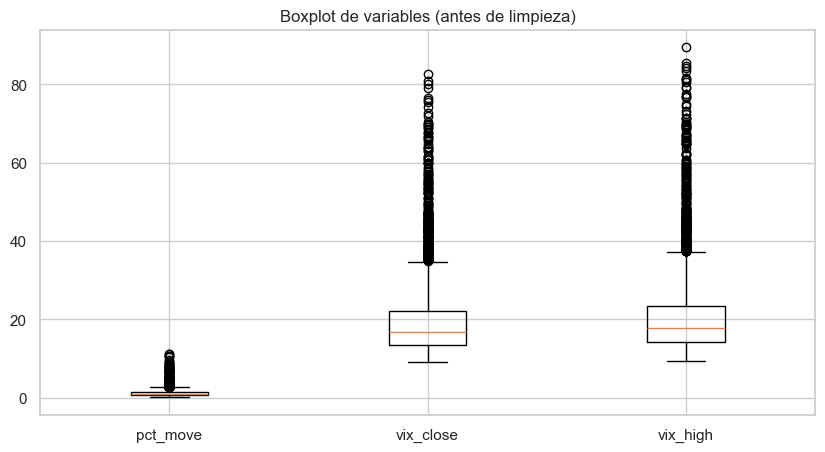

Filas originales: 5376 | Filas despues de limpiar vix_high: 5119


C:\Users\juana\AppData\Local\Temp\ipykernel_26116\2884877746.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_limpio[col] for col in features], labels=features)


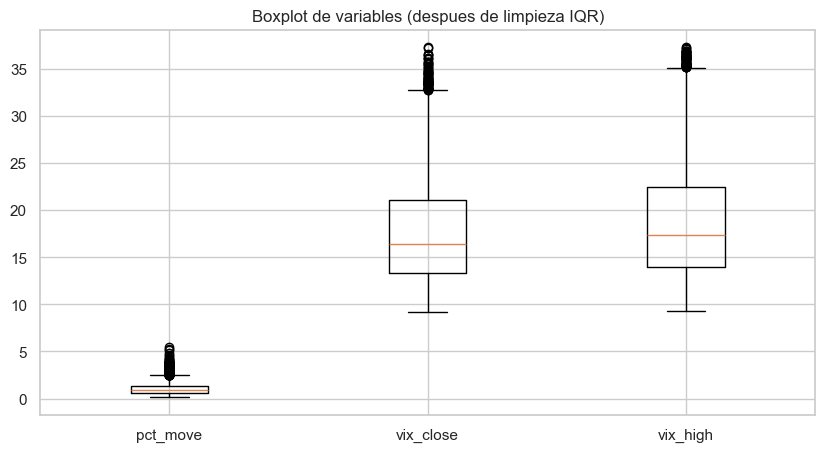

In [174]:
features = ["pct_move", "vix_close", "vix_high"]

plt.figure(figsize=(10, 5))
plt.boxplot([df[col] for col in features], labels=features)
plt.title("Boxplot de variables (antes de limpieza)")
plt.grid(True)
plt.show()

columna = "vix_high"

# Calibrar umbrales solo con entrenamiento para evitar leakage
train_cutoff = "2020-12-31"
train_df = df.loc[:train_cutoff]

Q1 = train_df[columna].quantile(0.25)
Q3 = train_df[columna].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_limpio = df[(df[columna] >= limite_inferior) & (df[columna] <= limite_superior)]

print(f"Filas originales: {len(df)} | Filas despues de limpiar {columna}: {len(df_limpio)}")

plt.figure(figsize=(10, 5))
plt.boxplot([df_limpio[col] for col in features], labels=features)
plt.title("Boxplot de variables (despues de limpieza IQR)")
plt.grid(True)
plt.show()


### Limpieza sin leakage (IQR entrenado en el pasado)

Los limites IQR se estiman solo con el tramo de entrenamiento y luego se aplican al resto del historico. Esto evita que la distribucion futura filtre filas del pasado y sesgue el backtest.


# Feature Engineering: Extracción de Presión Institucional (Wicks)

En el desarrollo de modelos predictivos financieros, utilizar precios absolutos (Open, High, Low, Close) genera problemas de no-estacionariedad. Para solucionar esto y dotar al algoritmo de información sobre la psicología del mercado, convertimos estos precios nominales en relaciones porcentuales mediante transformaciones logarítmicas.

Una de las métricas más predictivas de la acción del precio a corto plazo es la forma en la que el mercado cierra en relación a sus extremos diarios. Esto nos revela la convicción institucional en los últimos minutos de la sesión.

---

## 1. La Matemática detrás de las Mechas (Wicks)

En lugar de calcular la diferencia en puntos (ej. `High - Close`), la cual varía drásticamente dependiendo de si el activo vale 1000 o 5000 puntos, utilizamos la diferencia logarítmica. Matemáticamente, la resta de dos logaritmos naturales es equivalente al logaritmo de su cociente, lo cual nos da una aproximación perfecta a la **variación porcentual continua**.

$$\ln(A) - \ln(B) = \ln\left(rac{A}{B}
ight)  pprox 	ext{Cambio Porcentual}$$

### 1.1 Mecha Superior (Upper Wick): Presión de Venta
La mecha superior de una vela diaria representa todo el terreno que los compradores lograron ganar durante el día, pero que perdieron antes del cierre debido a una entrada agresiva de vendedores institucionales.

**Fórmula:**
$$	ext{Upper\_Wick} = \ln(	ext{High}) - \ln(	ext{Close})$$

* **¿Qué significa?** Si esta variable tiene un valor alto, indica que el precio fue rechazado fuertemente desde el máximo. Es una señal de agotamiento alcista y fuerte resistencia, lo que sugiere un sesgo de debilidad o mayor volatilidad a la baja para el día siguiente.

### 1.2 Mecha Inferior (Lower Wick): Presión de Compra
La mecha inferior representa el escenario opuesto: el precio cayó a un mínimo intradía, pero los compradores institucionales consideraron que el activo estaba barato y lo compraron agresivamente, elevando el precio hacia el cierre.

**Fórmula:**
$$	ext{Lower\_Wick} = \ln(	ext{Close}) - \ln(	ext{Low})$$

* **¿Qué significa?** Un valor alto en esta variable indica un fuerte rechazo del precio mínimo. Es una señal de soporte institucional y sugiere una posible estabilización o impulso alcista para la siguiente sesión.

---

## 2. Implementación en Pandas

Para asegurar que estas características se utilicen correctamente en un contexto predictivo (evitando el *Data Leakage*), el cálculo se realiza sobre los datos de la sesión y luego se desplaza un periodo hacia adelante (`shift(1)`), garantizando que el modelo "hoy" evalúe el comportamiento de las mechas de "ayer".

```python
import pandas as pd
import numpy as np

# 1. Cálculo de las presiones de cierre en escala logarítmica (Día actual 't')
df['Upper_Wick'] = np.log(df['high']) - np.log(df['close'])
df['Lower_Wick'] = np.log(df['close']) - np.log(df['low'])

# 2. Desplazamiento (Shift) para uso predictivo (El modelo lee los datos de 't-1')
df['Upper_Wick_lag1'] = df['Upper_Wick'].shift(1)
df['Lower_Wick_lag1'] = df['Lower_Wick'].shift(1)
```

## 3. Justificación para el Modelo de Reversión a la Media

Al incorporar `Upper_Wick_lag1` y `Lower_Wick_lag1` a nuestro DataFrame final, eliminamos el ruido de los precios absolutos y dotamos al modelo (ej. XGBoost o Random Forest) de *features* puramente relacionales. 

El modelo aprenderá, por ejemplo, que los días precedidos por una `Upper_Wick_lag1` extremadamente alta (rechazo vendedor) en conjunto con un alto `VIX_Rango_Log_lag1` (pánico en opciones), suelen resultar en jornadas con un rango `log_target` mucho más amplio, permitiendo al sistema ajustar sus umbrales de entrada y salida de forma dinámica y precisa.

In [ ]:
df = df_limpio.copy()

# Eliminar columnas que no se usaran

df = df.drop(columns=["volume", "pct_move", "vix_volume"], errors="ignore")

# Transformaciones logaritmicas y features

# 1. Precios base logarítmicos
df["close_log"] = np.log(df["close"])
df["high_log"] = np.log(df["high"])
df["low_log"] = np.log(df["low"])

# 2. CREACIÓN DE LOS TARGETS ESTACIONARIOS (Lo que el XGBoost va a predecir)
# Distancia desde el cierre de ayer hasta el máximo/mínimo de hoy
df["target_high"] = df["high_log"] - df["close_log"].shift(1)
df["target_low"] = df["low_log"] - df["close_log"].shift(1)

# 3. CREACIÓN DE FEATURES (Todo debe estar rezagado con .shift(1) si usa datos del día)
# Retorno de AYER
df["log_return"] = df["close_log"].diff().shift(1)

# Mechas de AYER (Esto ya lo tenías bien)
df["Upper_Wick_lag1"] = (df["high_log"] - df["close_log"]).shift(1)
df["Lower_Wick_lag1"] = (df["close_log"] - df["low_log"]).shift(1)

# VIX de AYER
df["VIX_Vol_Diaria_lag1"] = (df["vix_close"] / (100 * np.sqrt(252))).shift(1)
df["VIX_Rango_Log_lag1"] = (np.log(df["vix_high"]) - np.log(df["vix_low"])).shift(1)
df["close_log_lag1"] = df["close_log"].shift(1)

# 4. Eliminar precios en bruto (Actualizado)
df = df.drop(
    columns=[
        
        "vix_open",
        "vix_high",
        "vix_low",
        "vix_close",
        "vix_avg_hl",
        
    ],
    errors="ignore",
)

# Eliminar filas NaN generadas por los shifts
df = df.dropna()

display(df.head())



,open,high,low,close,close_log,high_log,low_log,target_high,target_low,log_return,Upper_Wick_lag1,Lower_Wick_lag1,VIX_Vol_Diaria_lag1,VIX_Rango_Log_lag1,close_log_lag1
date,,,,,,,,,,,,,,,
2005-01-05,1188.050049,1192.729980,1183.719971,1183.739990,7.076434,7.084000,7.076417,0.003931,-0.003651,-0.011740,0.014863,0.002242,0.008807,0.036650,7.080069
2005-01-06,1183.739990,1191.630005,1183.270020,1187.890015,7.079934,7.083077,7.076037,0.006643,-0.000397,-0.003634,0.007566,0.000017,0.008876,0.060713,7.076434
2005-01-07,1187.890015,1192.199951,1182.160034,1186.189941,7.078502,7.083556,7.075099,0.003622,-0.004835,0.003500,0.003143,0.003897,0.008555,0.055448,7.079934
2005-01-10,1186.189941,1194.780029,1184.800049,1190.250000,7.081919,7.085717,7.077329,0.007216,-0.001172,-0.001432,0.005054,0.003403,0.008498,0.043107,7.078502
2005-01-11,1190.250000,1190.250000,1180.430054,1182.989990,7.075800,7.081919,7.073634,0.000000,-0.008285,0.003417,0.003799,0.004589,0.008334,0.073722,7.081919


### Alineacion explicita del target

El target se define como el retorno del dia t (close[t] - close[t-1]) y las features permanecen rezagadas. Esto elimina el doble shift y evita desalineaciones silenciosas.

#### Exclusiones en walk-forward

Se excluye `log_target` de `feature_cols` en walk-forward para evitar leakage del precio de cierre del mismo dia.


In [176]:
# Target del dia t (retorno del cierre t vs t-1)
df["log_target"] = df["close_log"].diff()

# Mantener solo filas completas

df.dropna(inplace=True)

display(df.tail())


,open,high,low,close,close_log,high_log,low_log,target_high,target_low,log_return,Upper_Wick_lag1,Lower_Wick_lag1,VIX_Vol_Diaria_lag1,VIX_Rango_Log_lag1,close_log_lag1,log_target
date,,,,,,,,,,,,,,,,
2026-05-08,7362.970215,7401.500000,7362.970215,7398.930176,8.909091,8.909438,8.904219,0.008738,0.003518,-0.003810,0.006509,0.002164,0.010759,0.043548,8.900700,0.008390
2026-05-11,7385.310059,7428.970215,7384.200195,7412.839844,8.910969,8.913143,8.907098,0.004052,-0.001993,0.008390,0.000347,0.004872,0.010829,0.041345,8.909091,0.001878
2026-05-12,7390.629883,7409.569824,7338.540039,7400.959961,8.909365,8.910528,8.900895,-0.000441,-0.010074,0.001878,0.002174,0.003871,0.011578,0.031347,8.910969,-0.001604
2026-05-13,7409.120117,7460.040039,7375.129883,7444.250000,8.915197,8.917316,8.905869,0.007951,-0.003496,-0.001604,0.001163,0.008470,0.011333,0.063771,8.909365,0.005832
2026-05-14,7454.399902,7517.120117,7454.399902,7501.240234,8.922824,8.924938,8.916560,0.009741,0.001363,0.005832,0.002119,0.009328,0.011257,0.035402,8.915197,0.007626


### Analisis de correlaciones

Se revisa la matriz de correlacion para identificar colinealidad y variables redundantes antes de seleccionar modelos.


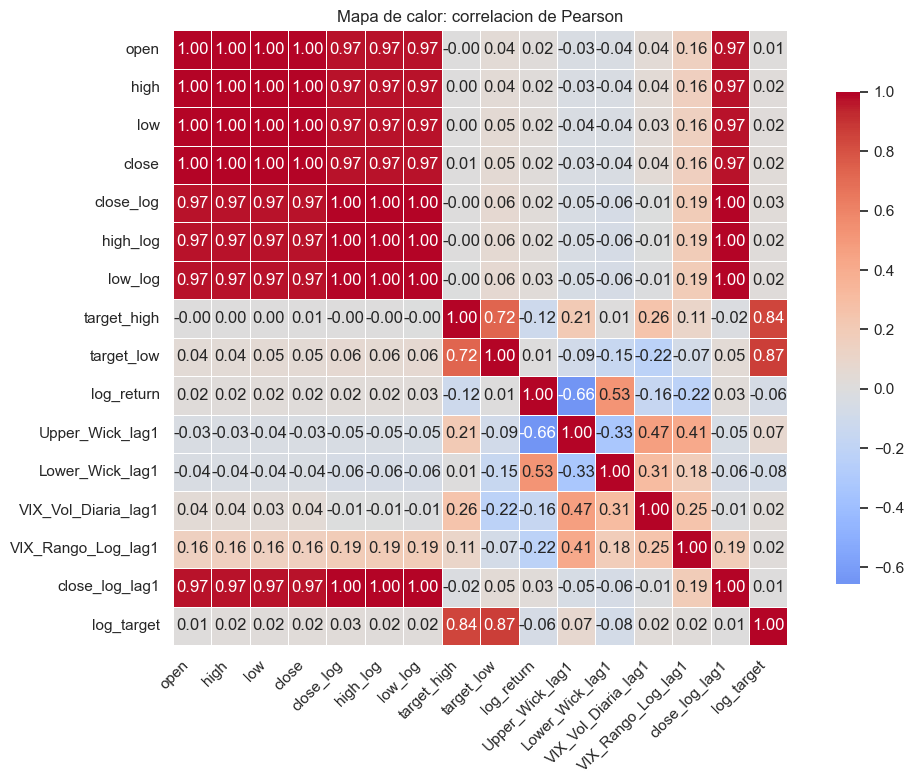

In [177]:
sns.set_theme(style="white")

numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr(method="pearson")

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Mapa de calor: correlacion de Pearson")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Corte temporal de entrenamiento

Se restringe el dataset al tramo 2000-2020 para entrenamiento y se eliminan columnas de precio crudo para evitar fugas de informacion.


In [178]:
model_df = df.loc[:"2020-12-31"].copy()

model_df = model_df.drop(
    columns=[
        "open",
        "high",
        "low",
        "close",
        "vix_open",
        "vix_high",
        "vix_low",
        "vix_close",
        "vix_avg_hl",
        "close_log_lag1",
        "high_log", 
        "low_log"
    ],errors="ignore",
)
    
display(model_df.tail())


,close_log,target_high,target_low,log_return,Upper_Wick_lag1,Lower_Wick_lag1,VIX_Vol_Diaria_lag1,VIX_Rango_Log_lag1,log_target
date,,,,,,,,,
2020-12-24,8.216915,0.003736,-0.000187,0.000746,0.005737,0.000198,0.014684,0.067697,0.003530
2020-12-28,8.225600,0.010062,0.005378,0.003530,0.000205,0.003717,0.013563,0.065152,0.008685
2020-12-29,8.223370,0.005542,-0.003231,0.008685,0.001378,0.003306,0.013670,0.044842,-0.002230
2020-12-30,8.224710,0.004708,0.000850,-0.002230,0.007772,0.001001,0.014539,0.122272,0.001341
2020-12-31,8.231128,0.007517,-0.001384,0.001341,0.003368,0.000490,0.014344,0.032487,0.006418


### Seleccion de modelos y validacion temporal

Se definen pipelines con escalado y modelos candidatos, evaluados con TimeSeriesSplit para respetar el orden temporal.


In [179]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor 

# 1. Separar Features (X) y Target (y)
X = model_df.drop(columns=['log_target'])
y = model_df['log_target']

# 2. Definir el validador cruzado para series de tiempo (5 particiones cronológicas)
tscv = TimeSeriesSplit(n_splits=5)

# 3. Diccionario de Pipelines (Escalador + Modelo)
pipelines = {
    'Multiple_Regression_Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ]),
    'Random_Forest': Pipeline([
        ('scaler', StandardScaler()), 
        ('model', RandomForestRegressor(random_state=777))
    ]),
    'Support_Vector_Machine': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR())
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        # objective='reg:squarederror' es el estándar para regresión en XGBoost
        ('model', XGBRegressor(objective='reg:squarederror', random_state=777)) 
    ])
}

# 4. Diccionario de Hiperparámetros a explorar para cada modelo
param_grids = {
    'Multiple_Regression_Ridge': {
        'model__alpha': [0.1, 1.0, 10.0, 100.0]
    },
    'Random_Forest': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [3, 5, 10, None],
        'model__min_samples_split': [2, 5, 10]
    },
    'Support_Vector_Machine': {
        'model__C': [0.1, 1, 10],      
        'model__gamma': ['scale', 'auto', 0.1, 0.01], 
        'model__kernel': ['rbf', 'linear'] 
    },
    'XGBoost': {
        'model__n_estimators': [50, 100, 200], # Cantidad de árboles
        'model__learning_rate': [0.01, 0.05, 0.1], # Tasa de aprendizaje (evita overfitting)
        'model__max_depth': [3, 5, 7], # Profundidad de cada árbol
        'model__subsample': [0.8, 1.0] # Fracción de datos a usar en cada árbol
    }
}

# 5. Ejecutar el Grid Search
resultados = []

print("Iniciando Torneo de Modelos...\n")

for nombre, pipeline in pipelines.items():
    print(f"Entrenando y buscando hiperparámetros para: {nombre}...")
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[nombre],
        cv=tscv,
        scoring='neg_root_mean_squared_error', 
        n_jobs=-1, 
        verbose=3
    )
    
    grid_search.fit(X, y)
    
    mejor_rmse = -grid_search.best_score_ 
    
    resultados.append({
        'Modelo': nombre,
        'Mejores_Parametros': grid_search.best_params_,
        'RMSE_Validacion': mejor_rmse
    })

# 6. Mostrar el ganador
df_resultados = pd.DataFrame(resultados).sort_values(by='RMSE_Validacion')
print("\n--- RESULTADOS FINALES DEL GRID SEARCH ---")
print(df_resultados[['Modelo', 'RMSE_Validacion']])
print("\nEl Modelo Ganador es el que tiene el MENOR RMSE.")

Iniciando Torneo de Modelos...

Entrenando y buscando hiperparámetros para: Multiple_Regression_Ridge...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Entrenando y buscando hiperparámetros para: Random_Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Entrenando y buscando hiperparámetros para: Support_Vector_Machine...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Entrenando y buscando hiperparámetros para: XGBoost...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

--- RESULTADOS FINALES DEL GRID SEARCH ---
                      Modelo  RMSE_Validacion
0  Multiple_Regression_Ridge         0.004818
1              Random_Forest         0.005600
3                    XGBoost         0.005713
2     Support_Vector_Machine         0.051582

El Modelo Ganador es el que tiene el MENOR RMSE.


### Interpretacion de RMSE en escala original

Se transforma el RMSE logaritmico a escala porcentual para facilitar su lectura economica.


In [180]:
import math 
e = math.e
for i in df_resultados["RMSE_Validacion"]:
    print(e**i)

1.004829849479388
1.005615887583852
1.0057293063487582
1.0529359700814078


### Backtest proxy con reglas de ejecucion

Se simula la ejecucion del trade con base en residuos OOS y un stop loss universal para estimar tasas de ejecucion y stop-out.


--- 🤖 BACKTEST PROXY: EJECUCIÓN DE TRADES ---
Total de días en la muestra: 3150
💤 Días sin operación (El precio no llegó a la banda): 1521 (48.29%)
⚡ Días CON operación (El precio tocó la banda): 1629 (51.71%)

--- DESGLOSE DE LOS TRADES EJECUTADOS ---
Total de trades analizados: 1629
✅ Trades que NO tocaron el Stop Loss (0.8%): 1027 (63.04% de los trades)
❌ Trades que SÍ tocaron el Stop Loss (0.8%): 602 (36.96% de los trades)


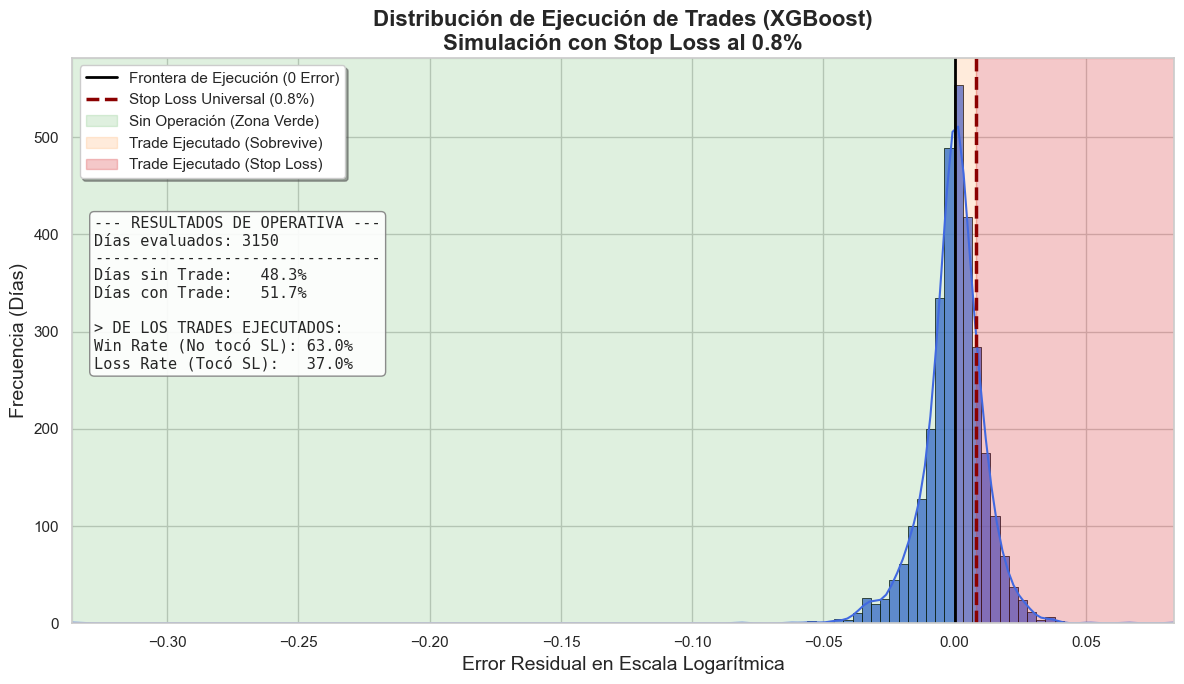

In [181]:

# ==========================================
# 1. PARÁMETROS GENERALIZADOS
# ==========================================
stop_loss_porcentaje = 0.8

# Límite logarítmico universal
limite_log_universal = np.log(1 + (stop_loss_porcentaje / 100))

# Residuos OOS con TimeSeriesSplit (evita in-sample)
from sklearn.model_selection import cross_val_predict

if "X" not in globals() or "y" not in globals() or "tscv" not in globals():
    raise ValueError("Faltan X, y o tscv. Ejecuta el bloque de modelado antes.")

if "grid_search" not in globals() or not hasattr(grid_search, "best_estimator_"):
    raise ValueError("Falta grid_search con best_estimator_. Ejecuta el grid search antes.")

oos_pred = cross_val_predict(grid_search.best_estimator_, X, y, cv=tscv, n_jobs=-1)
residuos = pd.Series(y.values - oos_pred, index=y.index, name="residuos_oos")

# ==========================================
# 2. LÓGICA DE EJECUCIÓN DE TRADING
# ==========================================
# Un trade se ejecuta SOLO si el rango real toca o cruza el predicho (Residuo >= 0)
dias_sin_trade = residuos[residuos < 0]
trades_ejecutados = residuos[residuos >= 0]

# De los trades ejecutados, ¿cuántos sobrevivieron y cuántos tocaron el Stop Loss?
trades_ganadores_o_salvados = trades_ejecutados[trades_ejecutados <= limite_log_universal]
trades_stopeados = trades_ejecutados[trades_ejecutados > limite_log_universal]

# Porcentajes globales
pct_sin_trade = (len(dias_sin_trade) / len(residuos)) * 100
pct_con_trade = (len(trades_ejecutados) / len(residuos)) * 100

# Porcentajes SOBRE LOS TRADES REALES (Win Rate real de la estrategia)
win_rate_estrategia = (len(trades_ganadores_o_salvados) / len(trades_ejecutados)) * 100 if len(trades_ejecutados) > 0 else 0
loss_rate_estrategia = (len(trades_stopeados) / len(trades_ejecutados)) * 100 if len(trades_ejecutados) > 0 else 0

print("--- 🤖 BACKTEST PROXY: EJECUCIÓN DE TRADES ---")
print(f"Total de días en la muestra: {len(residuos)}")
print(f"💤 Días sin operación (El precio no llegó a la banda): {len(dias_sin_trade)} ({pct_sin_trade:.2f}%)")
print(f"⚡ Días CON operación (El precio tocó la banda): {len(trades_ejecutados)} ({pct_con_trade:.2f}%)\n")

print("--- DESGLOSE DE LOS TRADES EJECUTADOS ---")
print(f"Total de trades analizados: {len(trades_ejecutados)}")
print(f"✅ Trades que NO tocaron el Stop Loss ({stop_loss_porcentaje}%): {len(trades_ganadores_o_salvados)} ({win_rate_estrategia:.2f}% de los trades)")
print(f"❌ Trades que SÍ tocaron el Stop Loss ({stop_loss_porcentaje}%): {len(trades_stopeados)} ({loss_rate_estrategia:.2f}% de los trades)")


# ==========================================
# 3. GRÁFICA CON PANEL DE MÉTRICAS
# ==========================================
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.histplot(residuos, bins=120, kde=True, color='royalblue', edgecolor='black', alpha=0.8)

# Líneas y Zonas
plt.axvline(0, color='black', linestyle='-', linewidth=2, label='Frontera de Ejecución (0 Error)')
plt.axvline(limite_log_universal, color='darkred', linestyle='--', linewidth=2.5, 
            label=f'Stop Loss Universal ({stop_loss_porcentaje}%)')

plt.axvspan(residuos.min(), 0, color='#2ca02c', alpha=0.15, label='Sin Operación (Zona Verde)')
plt.axvspan(0, limite_log_universal, color='#ff7f0e', alpha=0.15, label='Trade Ejecutado (Sobrevive)')
plt.axvspan(limite_log_universal, residuos.max(), color='#d62728', alpha=0.25, label='Trade Ejecutado (Stop Loss)')

# Textos
plt.title(f'Distribución de Ejecución de Trades (XGBoost)\nSimulación con Stop Loss al {stop_loss_porcentaje}%', 
          fontsize=16, fontweight='bold')
plt.xlabel('Error Residual en Escala Logarítmica', fontsize=14)
plt.ylabel('Frecuencia (Días)', fontsize=14)

plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.xlim(residuos.min(), residuos.max()) 

# --- PANEL DE TEXTO EN LA GRÁFICA ---
# Creamos el texto con los resultados exactos
# --- PANEL DE TEXTO EN LA GRÁFICA ---
# Eliminamos los emojis para evitar el error de Matplotlib
texto_metricas = (
    f"--- RESULTADOS DE OPERATIVA ---\n"
    f"Días evaluados: {len(residuos)}\n"
    f"-------------------------------\n"
    f"Días sin Trade:   {pct_sin_trade:.1f}%\n"
    f"Días con Trade:   {pct_con_trade:.1f}%\n\n"
    f"> DE LOS TRADES EJECUTADOS:\n"
    f"Win Rate (No tocó SL): {win_rate_estrategia:.1f}%\n"
    f"Loss Rate (Tocó SL):   {loss_rate_estrategia:.1f}%"
)

# Colocamos el cuadro de texto a la izquierda (x=0.02) y un poco más abajo (y=0.72) 
# para que no choque con la leyenda principal que está en 'upper left'
props_caja = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
plt.text(0.02, 0.72, texto_metricas, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', horizontalalignment='left', bbox=props_caja, family='monospace')

plt.tight_layout()
plt.show()

### Alineacion y PnL real (OOS)

Los residuos usados para la logica de ejecucion se calculan con predicciones out-of-sample usando TimeSeriesSplit, evitando inflar la tasa de acierto con datos in-sample.

#### Alineacion por indice (sin recortes)

Los calculos se alinean por indice temporal y eliminan el recorte ciego con `[-min_len:]`, evitando desincronizacion de fechas.

#### PnL real sin simulacion

El PnL se calcula con precios reales de entrada/cierre y reglas de stop, sin usar ruido aleatorio.

#### Distribucion sin sesgo de supervivencia

Las graficas de PnL incluyen trades ejecutados, stop-outs y dias sin trade (PnL=0) para evitar sesgo optimista.


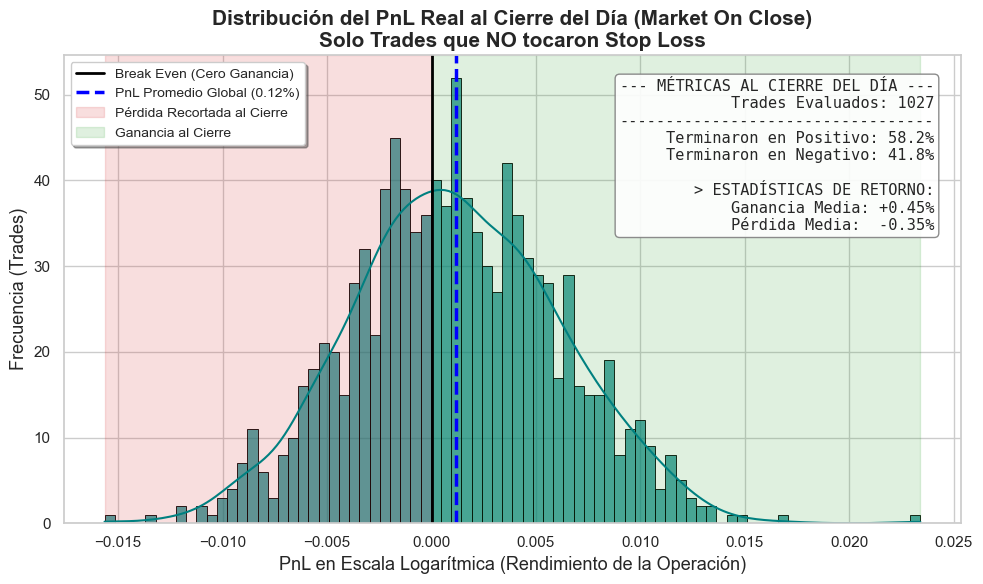

In [182]:

# ==========================================
# 1. PREPARACIÓN Y ALINEACIÓN DE DATOS
# ==========================================
# Verifica que las variables base existan
if "wf_results" not in globals():
    raise ValueError("Falta wf_results. Ejecuta el bloque walk-forward antes.")

if "sl_log" not in globals():
    stop_loss_porcentaje = 0.8
    sl_log = np.log(1 + (stop_loss_porcentaje / 100))

# DataFrame consolidado con precios reales y predicciones
aligned = wf_results[["pred_low", "pred_high", "low_log", "high_log", "close_log"]].copy()

# Logica de ejecucion y stops
long_exec = aligned["low_log"] <= aligned["pred_low"]
short_exec = aligned["high_log"] >= aligned["pred_high"]
both_touched = long_exec & short_exec
long_stop = long_exec & (aligned["low_log"] <= aligned["pred_low"] - sl_log)
short_stop = short_exec & (aligned["high_log"] >= aligned["pred_high"] + sl_log)

# Residuo por entrada (alineado por indice, sin recortes)
aligned["resid"] = np.nan
aligned.loc[long_exec, "resid"] = aligned["low_log"] - aligned["pred_low"]
aligned.loc[short_exec, "resid"] = aligned["high_log"] - aligned["pred_high"]

# PnL real en escala log (sin simulacion)
aligned["pnl_real"] = 0.0
aligned.loc[long_stop | short_stop | both_touched, "pnl_real"] = -sl_log
aligned.loc[long_exec & ~long_stop & ~both_touched, "pnl_real"] = aligned["close_log"] - aligned["pred_low"]
aligned.loc[short_exec & ~short_stop & ~both_touched, "pnl_real"] = aligned["pred_high"] - aligned["close_log"]


# ==========================================
# 3. FILTRO DE SOBREVIVIENTES Y MÉTRICAS
# ==========================================
# Máscara: Trades ejecutados que NO tocaron Stop Loss
executed = long_exec | short_exec
stop_out = long_stop | short_stop | both_touched
mask_sobrevivientes = executed & ~stop_out

# Extraemos SOLO el PnL de los trades que sobrevivieron
pnl_cierre_sobrevivientes = aligned.loc[mask_sobrevivientes, 'pnl_real']

if len(pnl_cierre_sobrevivientes) == 0:
    print("No hay trades sobrevivientes para graficar con los filtros actuales.")
else:
    # Cálculos estadísticos de los sobrevivientes
    ganadores_cierre = pnl_cierre_sobrevivientes[pnl_cierre_sobrevivientes > 0]
    perdedores_cierre = pnl_cierre_sobrevivientes[pnl_cierre_sobrevivientes <= 0]

    win_rate_cierre = (len(ganadores_cierre) / len(pnl_cierre_sobrevivientes)) * 100
    promedio_ganancia = np.mean(ganadores_cierre) * 100 if len(ganadores_cierre) > 0 else 0
    promedio_perdida = np.mean(perdedores_cierre) * 100 if len(perdedores_cierre) > 0 else 0
    media_pnl = np.mean(pnl_cierre_sobrevivientes)

    # ==========================================
    # 4. GRÁFICA DEL MARKET ON CLOSE (MOC)
    # ==========================================
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Histograma del PnL Real
    sns.histplot(pnl_cierre_sobrevivientes, bins=80, kde=True, color="teal", edgecolor="black", alpha=0.7)

    # Líneas de referencia
    plt.axvline(0, color="black", linestyle="-", linewidth=2, label="Break Even (Cero Ganancia)")
    plt.axvline(media_pnl, color="blue", linestyle="--", linewidth=2.5, 
                label=f"PnL Promedio Global ({media_pnl*100:.2f}%)")

    # Zonas de color para Ganancia y Pérdida (Ajustado al PnL Real)
    min_pnl = pnl_cierre_sobrevivientes.min()
    max_pnl = pnl_cierre_sobrevivientes.max()
    
    # Solo dibujamos la zona roja si hay pérdidas
    if min_pnl < 0:
        plt.axvspan(min_pnl, 0, color="#d62728", alpha=0.15, label="Pérdida Recortada al Cierre")
    # Solo dibujamos la zona verde si hay ganancias
    if max_pnl > 0:
        plt.axvspan(0, max_pnl, color="#2ca02c", alpha=0.15, label="Ganancia al Cierre")

    # Textos y formato
    plt.title("Distribución del PnL Real al Cierre del Día (Market On Close)\nSolo Trades que NO tocaron Stop Loss", 
              fontsize=15, fontweight="bold")
    plt.xlabel("PnL en Escala Logarítmica (Rendimiento de la Operación)", fontsize=13)
    plt.ylabel("Frecuencia (Trades)", fontsize=13)

    plt.legend(loc="upper left", fontsize=10, frameon=True, shadow=True)

    # Panel de Métricas
    texto_metricas = (
        f"--- MÉTRICAS AL CIERRE DEL DÍA ---\n"
        f"Trades Evaluados: {len(pnl_cierre_sobrevivientes)}\n"
        f"----------------------------------\n"
        f"Terminaron en Positivo: {win_rate_cierre:.1f}%\n"
        f"Terminaron en Negativo: {100 - win_rate_cierre:.1f}%\n\n"
        f"> ESTADÍSTICAS DE RETORNO:\n"
        f"Ganancia Media: +{promedio_ganancia:.2f}%\n"
        f"Pérdida Media:  {promedio_perdida:.2f}%"
    )

    props_caja = dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray")
    plt.text(0.97, 0.95, texto_metricas, transform=plt.gca().transAxes, fontsize=11,
             verticalalignment="top", horizontalalignment="right", bbox=props_caja, family="monospace")

    plt.tight_layout()
    plt.show()


### Ventana de validacion OOS

Se separa el periodo 2021-2026 para validacion fuera de muestra y para el walk-forward.


In [183]:
df_validation = df.loc["2021-01-01":"2026-05-13"].copy()

display(df_validation.head())


,open,high,low,close,close_log,high_log,low_log,target_high,target_low,log_return,Upper_Wick_lag1,Lower_Wick_lag1,VIX_Vol_Diaria_lag1,VIX_Rango_Log_lag1,close_log_lag1,log_target
date,,,,,,,,,,,,,,,,
2021-01-04,3764.610107,3769.989990,3662.709961,3700.649902,8.216264,8.234828,8.205959,0.003699,-0.025170,0.006418,0.001099,0.007802,0.014331,0.090419,8.231128,-0.014865
2021-01-05,3698.020020,3737.830078,3695.070068,3726.860107,8.223321,8.226261,8.214755,0.009997,-0.001509,-0.014865,0.018564,0.010305,0.016990,0.257648,8.216264,0.007058
2021-01-06,3712.199951,3783.040039,3705.340088,3748.139893,8.229015,8.238283,8.217530,0.014962,-0.005791,0.007058,0.002939,0.008567,0.015963,0.142563,8.223321,0.005694
2021-01-07,3764.709961,3811.550049,3764.709961,3803.790039,8.243753,8.245791,8.233426,0.016776,0.004411,0.005694,0.009268,0.011485,0.015793,0.189896,8.229015,0.014738
2021-01-08,3815.050049,3826.689941,3783.600098,3824.679932,8.249230,8.249755,8.238431,0.006002,-0.005322,0.014738,0.002038,0.010327,0.014092,0.071955,8.243753,0.005477


### Walk-forward y logica de trading OOS

Se reentrena el modelo por bloques temporales, se reconstruyen precios predichos y se calcula PnL con reglas de ejecucion y stop loss.


--- WALK-FORWARD OOS (2021-2026) ---
Dias evaluados: 1335
Dias sin trade: 343 (25.69%)
Trades ejecutados: 992
Stop-Outs: 221 (22.28%)
Sobrevivientes: 771 (77.72%)
EV (log): 0.001732


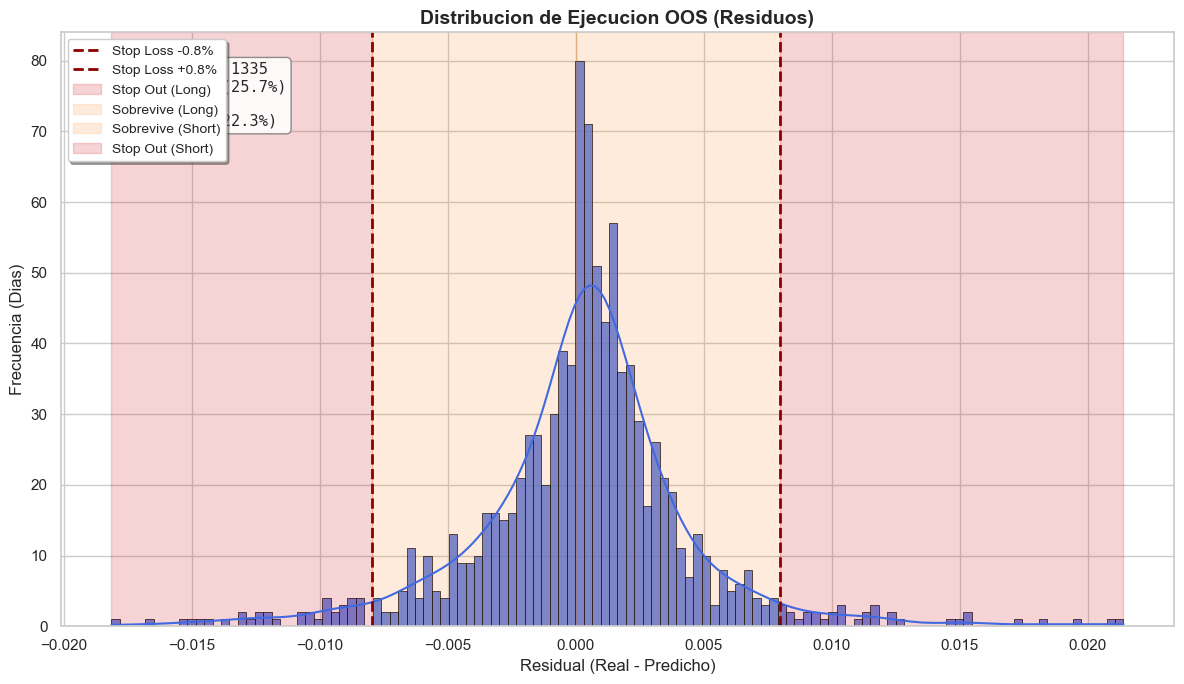

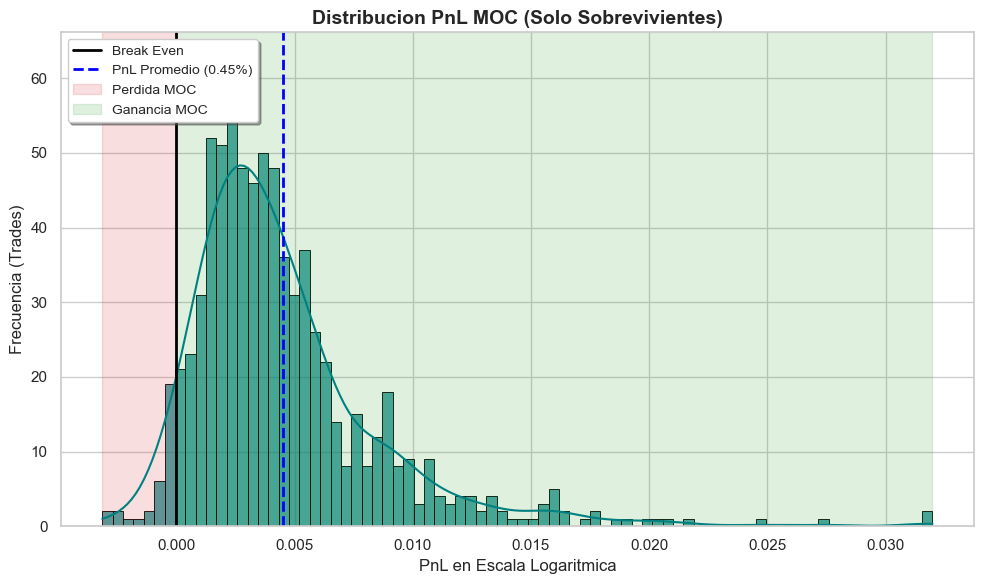

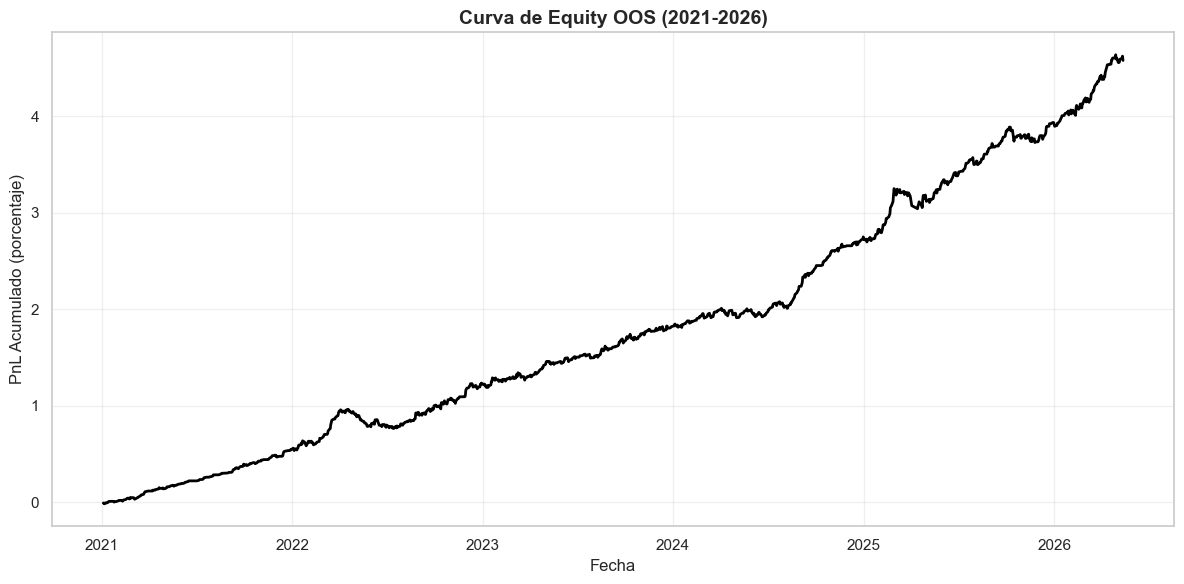

In [ ]:
from xgboost import XGBRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIGURACION WALK-FORWARD (EXPANDING)
# ==========================================
retrain_freq = "YS"  # "YS" = Year Start
stop_loss_porcentaje = 0.8
sl_log = np.log(1 + (stop_loss_porcentaje / 100))

# Asegúrate de que el df base ya tiene las variables corregidas
wf_data = df.copy()

if not isinstance(wf_data.index, pd.DatetimeIndex):
    wf_data.index = pd.to_datetime(wf_data.index)

if "df_validation" not in globals():
    df_validation = wf_data.loc["2021-01-01":"2026-05-13"].copy()

if df_validation.empty:
    raise ValueError("df_validation esta vacio. Revisa el rango de fechas.")

df_validation = df_validation.sort_index()

# Novedad 1: Se exigen las columnas de los targets y el lag para reconstruir el precio
required_cols = {"close_log", "high_log", "low_log", "target_low", "target_high", "close_log_lag1"}
missing_cols = required_cols - set(wf_data.columns)
if missing_cols:
    raise ValueError(f"Faltan columnas requeridas en df: {missing_cols}")

# Novedad 2: Filtrado estricto de features (se excluyen los precios crudos)
leak_cols = {"log_target"}
feature_cols = [
    c for c in wf_data.columns
    if c not in required_cols and c not in leak_cols
    and c not in ["close", "high", "low", "open"]
]

if not feature_cols:
    raise ValueError("No hay columnas de features disponibles para entrenar.")

xgb_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:squarederror",
    "random_state": 777,
}

if "grid_search" in globals() and hasattr(grid_search, "best_params_"):
    best = {k.replace("model__", ""): v for k, v in grid_search.best_params_.items() if k.startswith("model__")}
    xgb_params.update(best)

# Cortes OOS segun rango real
oos_start = df_validation.index.min()
oos_end = df_validation.index.max()

cutoffs = pd.date_range(start=oos_start, end=oos_end, freq=retrain_freq).to_list()
if not cutoffs or cutoffs[0] != oos_start:
    cutoffs = [oos_start] + cutoffs
cutoffs = sorted(set(cutoffs))

results_blocks = []

for i in range(len(cutoffs)):
    test_start = cutoffs[i]
    if test_start > oos_end:
        break

    if i < len(cutoffs) - 1:
        test_end = cutoffs[i + 1] - pd.Timedelta(days=1)
    else:
        test_end = oos_end

    train_end = test_start - pd.Timedelta(days=1)
    train_df = wf_data.loc[:train_end]
    test_df = df_validation.loc[test_start:test_end]

    # Ajuste de dropna para incluir los nuevos targets
    train_df = train_df.dropna(subset=feature_cols + ["target_low", "target_high"])
    test_df = test_df.dropna(subset=feature_cols + ["target_low", "target_high", "close_log_lag1"])

    if train_df.empty or test_df.empty:
        continue

    model_low = XGBRegressor(**xgb_params)
    model_high = XGBRegressor(**xgb_params)

    # Novedad 3: Entrenar el modelo con los targets estacionarios
    model_low.fit(train_df[feature_cols], train_df["target_low"])
    model_high.fit(train_df[feature_cols], train_df["target_high"])

    # Novedad 4: Las predicciones ahora son distancias, no precios absolutos
    pred_distancia_low = model_low.predict(test_df[feature_cols])
    pred_distancia_high = model_high.predict(test_df[feature_cols])

    # Novedad 5: Reconstruccion del precio predicho (Distancia predicha + Cierre de Ayer)
    pred_low_reconstruido = pred_distancia_low + test_df["close_log_lag1"]
    pred_high_reconstruido = pred_distancia_high + test_df["close_log_lag1"]

    # Guardar bloque con las predicciones transformadas y los datos reales
    block = pd.DataFrame(
        {
            "pred_low": pred_low_reconstruido,
            "pred_high": pred_high_reconstruido,
            "low_log": test_df["low_log"],
            "high_log": test_df["high_log"],
            "close_log": test_df["close_log"],
        },
        index=test_df.index,
    )
    results_blocks.append(block)

if not results_blocks:
    raise ValueError("No se generaron bloques OOS. Revisa fechas y datos.")

wf_results = pd.concat(results_blocks).sort_index()

# ==========================================
# 2. LOGICA DE TRADING Y PNL (SIN CAMBIOS)
# ==========================================
long_touched = wf_results["low_log"] <= wf_results["pred_low"]
short_touched = wf_results["high_log"] >= wf_results["pred_high"]
both_touched = long_touched & short_touched

long_stop = long_touched & (wf_results["low_log"] <= wf_results["pred_low"] - sl_log)
short_stop = short_touched & (wf_results["high_log"] >= wf_results["pred_high"] + sl_log)

executed = long_touched | short_touched
stop_out = long_stop | short_stop | both_touched
survivors = executed & ~stop_out

pnl = pd.Series(0.0, index=wf_results.index)

pnl[long_stop | short_stop | both_touched] = -sl_log
pnl[long_touched & ~long_stop & ~both_touched] = wf_results["close_log"] - wf_results["pred_low"]
pnl[short_touched & ~short_stop & ~both_touched] = wf_results["pred_high"] - wf_results["close_log"]

wf_results["pnl"] = pnl

n_total = len(wf_results)
n_no_trade = (~executed).sum()
n_exec = executed.sum()
n_stop = stop_out.sum()
n_surv = survivors.sum()

avg_surv = wf_results.loc[survivors, "pnl"].mean() if n_surv > 0 else 0

if n_exec > 0:
    ev = (avg_surv * (n_surv / n_exec)) + (-sl_log * (n_stop / n_exec))
else:
    ev = 0

print("--- WALK-FORWARD OOS (2021-2026) ---")
print(f"Dias evaluados: {n_total}")
print(f"Dias sin trade: {n_no_trade} ({(n_no_trade / n_total) * 100:.2f}%)")
print(f"Trades ejecutados: {n_exec}")
print(f"Stop-Outs: {n_stop} ({(n_stop / n_exec) * 100:.2f}%)" if n_exec > 0 else "Stop-Outs: 0")
print(f"Sobrevivientes: {n_surv} ({(n_surv / n_exec) * 100:.2f}%)" if n_exec > 0 else "Sobrevivientes: 0")
print(f"EV (log): {ev:.6f}")

# ==========================================
# 3. GRAFICA 1: DISTRIBUCION DE EJECUCION
# ==========================================
residual_entry = pd.Series(np.nan, index=wf_results.index)
residual_entry[long_touched] = wf_results.loc[long_touched, "low_log"] - wf_results.loc[long_touched, "pred_low"]
residual_entry[short_touched] = wf_results.loc[short_touched, "high_log"] - wf_results.loc[short_touched, "pred_high"]

residual_values = residual_entry.dropna()

if len(residual_values) == 0:
    print("No hay trades ejecutados para la grafica de residuos.")
else:
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    sns.histplot(residual_values, bins=120, kde=True, color="royalblue", edgecolor="black", alpha=0.8)
    plt.axvline(-sl_log, color="darkred", linestyle="--", linewidth=2, label=f"Stop Loss -{stop_loss_porcentaje}%")
    plt.axvline(sl_log, color="darkred", linestyle="--", linewidth=2, label=f"Stop Loss +{stop_loss_porcentaje}%")
    plt.axvspan(residual_values.min(), -sl_log, color="#d62728", alpha=0.2, label="Stop Out (Long)")
    plt.axvspan(-sl_log, 0, color="#ff7f0e", alpha=0.15, label="Sobrevive (Long)")
    plt.axvspan(0, sl_log, color="#ff7f0e", alpha=0.15, label="Sobrevive (Short)")
    plt.axvspan(sl_log, residual_values.max(), color="#d62728", alpha=0.2, label="Stop Out (Short)")
    plt.title("Distribucion de Ejecucion OOS (Residuos)", fontsize=14, fontweight="bold")
    plt.xlabel("Residual (Real - Predicho)")
    plt.ylabel("Frecuencia (Dias)")
    plt.legend(loc="upper left", fontsize=10, frameon=True, shadow=True)

    stop_text = f"Stop-Out: {n_stop} ({(n_stop / n_exec) * 100:.1f}%)" if n_exec > 0 else "Stop-Out: 0"
    texto_metricas = (
        f"Dias evaluados: {n_total}\n"
        f"Sin trade: {n_no_trade} ({(n_no_trade / n_total) * 100:.1f}%)\n"
        f"Trades: {n_exec}\n"
        f"{stop_text}"
    )
    props_caja = dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray")
    plt.text(0.02, 0.95, texto_metricas, transform=plt.gca().transAxes, fontsize=11, verticalalignment="top", horizontalalignment="left", bbox=props_caja, family="monospace")
    plt.tight_layout()
    plt.show()

# ==========================================
# 3B. COMPARACION IN-SAMPLE VS OOS (ERROR)
# ==========================================
if "residuos" not in globals():
    print("No hay variable 'residuos' para comparar In-Sample vs OOS.")
elif len(residual_values) == 0:
    print("No hay residuos OOS para comparar.")
else:
    residuos_in = pd.Series(residuos).dropna()
    if residuos_in.empty:
        print("No hay residuos In-Sample para comparar.")
    else:
        plt.figure(figsize=(12, 6))
        sns.set_style("whitegrid")
        sns.kdeplot(residuos_in, label="In-Sample", color="gray", linewidth=2)
        sns.kdeplot(residual_values, label="OOS", color="royalblue", linewidth=2)
        plt.axvline(0, color="black", linestyle="-", linewidth=2)
        plt.axvline(-sl_log, color="darkred", linestyle="--", linewidth=1.5)
        plt.axvline(sl_log, color="darkred", linestyle="--", linewidth=1.5)
        plt.title("Comparacion de Error: In-Sample vs OOS", fontsize=14, fontweight="bold")
        plt.xlabel("Residual (Real - Predicho)")
        plt.ylabel("Densidad")
        plt.legend(loc="upper left", fontsize=10, frameon=True, shadow=True)

        mu_in = residuos_in.mean()
        std_in = residuos_in.std()
        mu_oos = residual_values.mean()
        std_oos = residual_values.std()

        texto_comp = (
            f"In-Sample: media={mu_in:.4f}, std={std_in:.4f}\n"
            f"OOS: media={mu_oos:.4f}, std={std_oos:.4f}"
        )
        props_caja = dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray")
        plt.text(0.02, 0.95, texto_comp, transform=plt.gca().transAxes, fontsize=11,
                 verticalalignment="top", horizontalalignment="left", bbox=props_caja, family="monospace")
        plt.tight_layout()
        plt.show()

# ==========================================
# 4. GRAFICA 2: PNL MOC (INCLUYE NO-TRADE Y STOP-OUT)
# ==========================================
pnl_all = wf_results["pnl"]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
if len(pnl_all) > 0:
    sns.histplot(pnl_all, bins=80, kde=True, color="teal", edgecolor="black", alpha=0.7)
    plt.axvline(0, color="black", linestyle="-", linewidth=2, label="Break Even")
    media_pnl = pnl_all.mean()
    plt.axvline(media_pnl, color="blue", linestyle="--", linewidth=2, label=f"PnL Promedio ({media_pnl*100:.2f}%)")
    plt.axvspan(pnl_all.min(), 0, color="#d62728", alpha=0.15, label="Perdida MOC")
    plt.axvspan(0, pnl_all.max(), color="#2ca02c", alpha=0.15, label="Ganancia MOC")
    plt.title("Distribucion PnL MOC (Incluye no-trade y stop-outs)", fontsize=14, fontweight="bold")
    plt.xlabel("PnL en Escala Logaritmica")
    plt.ylabel("Frecuencia (Trades)")
    plt.legend(loc="upper left", fontsize=10, frameon=True, shadow=True)
else:
    plt.title("Distribucion PnL MOC (Sin Trades)")
plt.tight_layout()
plt.show()

# ==========================================
# 5. GRAFICA 3: CURVA DE EQUITY OOS
# ==========================================
equity_curve = np.exp(wf_results["pnl"].cumsum()) - 1

plt.figure(figsize=(12, 6))
plt.plot(equity_curve.index, equity_curve.values, color="black", linewidth=2)
plt.title("Curva de Equity OOS (2021-2026)", fontsize=14, fontweight="bold")
plt.xlabel("Fecha")
plt.ylabel("PnL Acumulado (porcentaje)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
